# Experiment #4: Decision Tree (ID3) to Predict Playing Tennis

**Dataset:** Play Tennis - 14 example days (Outlook, Temperature, Humidity, Wind - Play Tennis)  
**Name:** Adithya Rajesh  |  **Class:** R3AI  |  **Roll No:** B25CTA07  |  **Date:** 10-07-2026

**Objective:** Implement the **ID3 decision-tree algorithm** using **entropy** as the splitting criterion. We encode the categorical attributes, train and evaluate the model, visualise the decision tree, and predict the outcome for a new test case.

> **Note:** The notebook must stay in the same folder as `play_tennis_dataset.csv`.


## 1. Load the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report)

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
%matplotlib inline

In [2]:
df = pd.read_csv('play_tennis_dataset.csv')
print('Shape:', df.shape)
print('Target distribution:'); print(df['Play Tennis'].value_counts())
df

Shape: (14, 6)
Target distribution:
Play Tennis
Yes    9
No     5
Name: count, dtype: int64


,Day,Outlook,Temperature,Humidity,Wind,Play Tennis
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes
5,D6,Rain,Cool,Normal,Strong,No
6,D7,Overcast,Cool,Normal,Strong,Yes
7,D8,Sunny,Mild,High,Weak,No
8,D9,Sunny,Cool,Normal,Weak,Yes
9,D10,Rain,Mild,Normal,Weak,Yes


## 2. Encode the Categorical Attributes

The features `Outlook`, `Temperature`, `Humidity`, `Wind` and the target `Play Tennis` are categorical. We convert them into numbers using **Label Encoding** so the decision tree can be trained. The `Day` column is just an identifier, so it is not used as a feature.

Encoding used (alphabetical): Outlook (Overcast=0, Rain=1, Sunny=2) - Temperature (Cool=0, Hot=1, Mild=2) - Humidity (High=0, Low=1, Normal=2) - Wind (Strong=0, Weak=1) - Play Tennis (No=0, Yes=1).


In [3]:
features = ['Outlook', 'Temperature', 'Humidity', 'Wind']

encoders = {}
X = df[features]
for col in features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

le_y = LabelEncoder()
y = le_y.fit_transform(df['Play Tennis'])

print('Encoded feature matrix:'); X
print('Encoded target y:', y)

Encoded feature matrix:
Encoded target y: [0 0 1 1 1 0 1 0 1 1 1 1 1 0]


## 3. Entropy and Information Gain (ID3 Splitting Criterion)

ID3 selects the attribute with the **highest information gain** (lowest entropy) at each node. Let us compute this by hand for the root level.


In [4]:
def entropy(labels):
    _, counts = np.unique(labels, return_counts=True)
    p = counts / counts.sum()
    return -np.sum(p * np.log2(p))

labels_n = df['Play Tennis']
E_target = entropy(labels_n)

def info_gain(df_, feature, target='Play Tennis'):
    E = entropy(df_[target])
    for value in df_[feature].unique():
        subset = df_[df_[feature] == value]
        E -= (len(subset) / len(df_)) * entropy(subset[target])
    return E

print(f'Entropy of target (Play Tennis)    : {E_target:.4f}')
print()
gains = {f: info_gain(df, f) for f in ['Outlook', 'Temperature', 'Humidity', 'Wind']}
for f, g in gains.items():
    print(f'Information gain of {f:11s}: {g:.4f}')

best = max(gains, key=gains.get)
print(f'\nRoot attribute selected by ID3: {best} (highest gain)')

Entropy of target (Play Tennis)    : 0.9403

Information gain of Outlook    : 0.2467
Information gain of Temperature: 0.0292
Information gain of Humidity   : 0.1518
Information gain of Wind       : 0.0481

Root attribute selected by ID3: Outlook (highest gain)


In [5]:
E_outlook = E_target - gains['Outlook']
print(f'Conditional entropy H(Play Tennis | Outlook) : {E_outlook:.4f}')
print(f'Gain(Outlook) = {E_target:.4f} - {E_outlook:.4f} = {gains["Outlook"]:.4f}')

Conditional entropy H(Play Tennis | Outlook) : 0.6935
Gain(Outlook) = 0.9403 - 0.6935 = 0.2467


## 4. Split the Data and Train the ID3 Decision Tree

We split into a training (75%) and test (25%) set and train `DecisionTreeClassifier` with `criterion='entropy'` (the ID3 approach).


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=16, stratify=y)

print('Training set:', X_train.shape, '| Test set:', X_test.shape)

Training set: (10, 4) | Test set: (4, 4)


In [7]:
tree = DecisionTreeClassifier(criterion='entropy', random_state=16)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
print('Model trained successfully | Test predictions:', y_pred)

Model trained successfully | Test predictions: [1 0 0 1]


## 5. Evaluate the Model

Accuracy, confusion matrix and classification report are computed on the test set.


In [8]:
print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
print()
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

Accuracy: 0.75

Confusion matrix:
[[1 0]
 [1 2]]

              precision    recall  f1-score   support

          No       0.50      1.00      0.67         1
         Yes       1.00      0.67      0.80         3

    accuracy                           0.75         4
   macro avg       0.75      0.83      0.73         4
weighted avg       0.88      0.75      0.77         4



## 6. Visualise the Decision Tree

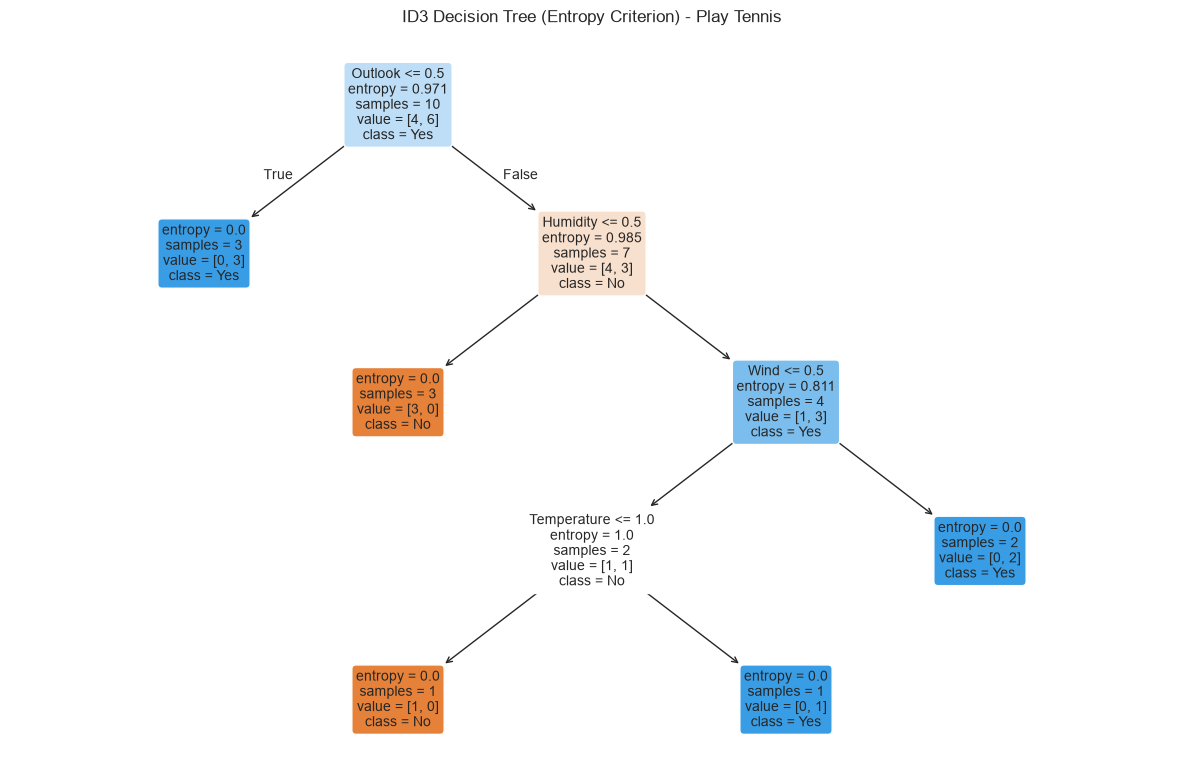

In [9]:
plt.figure(figsize=(12, 8))
plot_tree(tree, feature_names=list(X.columns), class_names=['No', 'Yes'],
          filled=True, rounded=True, fontsize=10)
plt.title('ID3 Decision Tree (Entropy Criterion) - Play Tennis')
plt.tight_layout()
plt.show()

In [10]:
print(export_text(tree, feature_names=list(X.columns)))

|--- Outlook <= 0.50
|   |--- class: 1
|--- Outlook >  0.50
|   |--- Humidity <= 0.50
|   |   |--- class: 0
|   |--- Humidity >  0.50
|   |   |--- Wind <= 0.50
|   |   |   |--- Temperature <= 1.00
|   |   |   |   |--- class: 0
|   |   |   |--- Temperature >  1.00
|   |   |   |   |--- class: 1
|   |   |--- Wind >  0.50
|   |   |   |--- class: 1



## 7. Predict the Outcome for a New Test Case

New test case: **Outlook = Sunny, Temperature = Hot, Humidity = High, Wind = Weak** - should tennis be played?

We encode the case with the same label encoders and predict.


In [11]:
new_case = pd.DataFrame([{'Outlook': 'Sunny', 'Temperature': 'Hot',
                          'Humidity': 'High', 'Wind': 'Weak'}])

for col in new_case.columns:
    new_case[col] = encoders[col].transform(new_case[col])

print('Encoded new case:', new_case[list(X.columns)].values)
prediction = tree.predict(new_case)[0]
probability = tree.predict_proba(new_case)[0]

print(f'Predicted class : {prediction} ->', 'Yes - play tennis' if prediction == 1 else 'No - do not play')
print(f'P(No)  : {probability[0]:.4f}')
print(f'P(Yes) : {probability[1]:.4f}')

Encoded new case: [[2 1 0 1]]
Predicted class : 0 -> No - do not play
P(No)  : 1.0000
P(Yes) : 0.0000


---
## Inference & Analysis

- **Entropy / gain:** the manual calculation identified **Outlook** as the root attribute for the ID3 tree, with the highest information gain (**0.2467**) starting from target entropy **0.9403**. This matches the tree learned by the model.
- **Accuracy** on the test set was **0.75** (3 of 4 test days classified correctly) - the one error was an actual "Yes" day predicted as "No", as the confusion matrix `[[1, 0], [1, 2]]` shows. This is expected for such a small dataset.
- **Decision tree:** the visualisation shows ID3 splitting on **Outlook** first (Overcast -> Yes), then using **Humidity** for the remaining days, with Wind/Temperature refining the last branch of the tree.
- **New test case** (Sunny, Hot, High, Weak): predicted **No** - tennis should **not** be played (P(No) = 1.0), in agreement with the first day of the dataset.

---
**End of Experiment #4.**
